In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#unit=pd.read_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zona_logistica\esp840_1620_02_2026.csv',sep=',') #for csv files.
unit=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\Export.xlsx') #For xls files.
unit.info()

<class 'pandas.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  254 non-null    str  
 1   Message  254 non-null    str  
 2   Status   254 non-null    str  
dtypes: str(3)
memory usage: 6.1 KB


Odometer

     Odometer in  Odometer en miles
0       29426614       18284.844568
1       29426614       18284.844568
2       29426614       18284.844568
3       29426614       18284.844568
4       29426614       18284.844568
..           ...                ...
101     29532201       18350.453268
102     29532355       18350.548959
103     29532378       18350.563250
104     29532811       18350.832304
105     29532972       18350.932345

[106 rows x 2 columns]


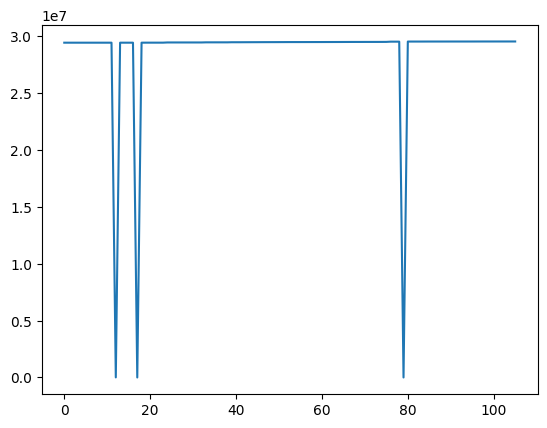

In [3]:
aux=[]
aux_miles=[]
x_axis=[]
unit_odometer=pd.DataFrame()
cont=0

for i in range (0,unit.shape[0]):
    l=len(unit.iloc[i,2])
    #print('Len=',l)
    if l<180:
        aux.append(int(unit.iloc[i,2][68:76],16))
        aux_miles.append((int(unit.iloc[i,2][68:76],16))*0.000621371)
        cont=cont+1     

unit_odometer['Odometer in']=aux
unit_odometer['Odometer en miles']=aux_miles

for i in range(0,cont):
    x_axis.append(i)

print(unit_odometer)
unit_odometer
plt.plot(x_axis,aux)

Harsh turn

Event codes only for No User messages.
Harsh Turn: 35 on Hex, 53 on Dec

In [4]:
event_code=[]

for i in range(0,unit.shape[0]):
    event_code.append(unit.iloc[i,2][64:68])
    if unit.iloc[i,2][64:66]=='35': # Put the Even Code to look for.
        print(unit.iloc[i,2][64:66],' -> ',unit.iloc[i,0])

Satellite number

In [5]:
cont=0
for i in range(0,unit.shape[0]):
    l=len(unit.iloc[i,2])
    if l>92:
        sn=int(unit.iloc[i,2][82:84],16)        
        if sn<5:
            print(unit.iloc[i,0], ' -> ',sn)
            cont=cont+1
    if l<93:
        sn=int(unit.iloc[i,2][55:57],16)        
        if sn<5:
            print(unit.iloc[i,0], ' -> ',sn)
            cont=cont+1

print('Messages with satellite number < 5: ',cont)
        

2026-05-03 19:10:44.979  ->  0
2026-05-03 19:10:45.416  ->  0
2026-05-03 19:10:45.865  ->  0
2026-05-03 19:10:46.322  ->  0
2026-05-03 19:10:46.772  ->  0
2026-05-03 19:10:47.636  ->  0
2026-05-03 19:16:58.035  ->  2
2026-05-03 19:23:58.677  ->  2
2026-05-03 22:04:24.564  ->  0
2026-05-03 22:04:25.016  ->  0
2026-05-03 22:07:21.089  ->  0
2026-05-03 22:09:21.081  ->  0
2026-05-03 23:33:37.636  ->  0
2026-05-04 00:40:26.065  ->  1
2026-05-04 03:16:48.300  ->  0
2026-05-04 03:17:39.263  ->  0
2026-05-04 03:26:36.067  ->  0
2026-05-04 12:40:48.186  ->  0
2026-05-04 12:41:00.332  ->  0
2026-05-04 12:43:48.295  ->  0
2026-05-04 14:11:23.671  ->  0
2026-05-04 14:18:11.619  ->  0
2026-05-04 14:26:12.789  ->  0
2026-05-04 14:33:03.929  ->  0
2026-05-04 14:39:12.084  ->  0
2026-05-04 14:46:11.791  ->  4
2026-05-04 14:46:13.606  ->  2
2026-05-04 14:53:11.034  ->  0
2026-05-04 15:01:01.126  ->  4
2026-05-04 15:01:26.916  ->  0
2026-05-04 15:08:01.166  ->  0
2026-05-04 15:13:15.507  ->  1
2026-05-

Temperature

In [6]:
accum3=float(input('Type Accum 3 value: '))
celsius_temp=accum3*0.0625
farenheit_temp=(celsius_temp*9)/5+32
print('Celsius: ',celsius_temp,'farenheit: ',farenheit_temp)

Celsius:  21.5625 farenheit:  70.8125


In [7]:
aux_temp=[]
for i in range(0,unit.shape[0]):    
    aux_temp.append(float(int(unit.iloc[i,2][96:100],16)*0.0625))
aux_temp

ValueError: invalid literal for int() with base 16: ''

Binary inputs

In [ ]:
for i in range(0,unit.shape[0]):   
    if unit.iloc[i,2][64:66]=='0C': # Put the Even Code to look for.
        cont=cont+1
        print(bin(int(unit.iloc[i,2][62:64],16)),' -> ',unit.iloc[i,0])
print("Total event codes 0C input2 Off: ",cont)

0b10  ->  2026-02-20 18:16:02.210
Total event codes 0C input2 Off:  9960


In [ ]:
sequence=[]
sequence.append(unit.iloc[0,2][24:28])
sequence

['9336']

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 16, 166, 0, 0, 0, 0, 0, 25, 25, 17, 1, 1, 1, 0, 0, 0, 0, 0, 32, 0, 0, 1, 12, 0, 4, 12, 9, 3, 0, 0, 12, 52, 45, 35, 65, 45, 50, 55, 54, 54, 42, 21, 31, 18, 4, 13, 9, 30, 32, 37, 26, 28, 23, 46, 13, 45, 27, 2, 21, 27, 15, 1, 41, 54, 59, 3, 0, 0, 52, 15, 0, 0, 0, 54, 0, 0, 3, 32, 8, 1, 9, 9, 8, 9, 9, 21, 15, 16, 11, 11, 10, 9, 10, 9, 1] 106


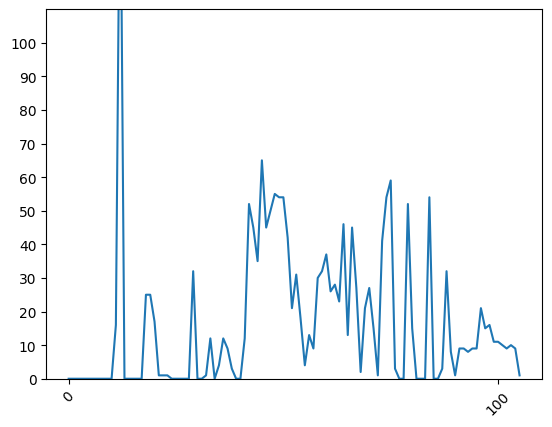

In [8]:
aux=[]
aux_kmh=[]
x_axis=[]
unit_speed=pd.DataFrame()
cont=0

for i in range (0,unit.shape[0]):
    l=len(unit.iloc[i,2])
    #print('Len=',l)
    if l<180:
        aux.append(int(unit.iloc[i,2][56:58],16))
        #aux_kmh.append((int(unit.iloc[i,2][68:76],16))*0.036)
        cont=cont+1     

unit_speed['Speed Km-h']=aux
#unit_speed['Speed m-s']=aux_kmh

for i in range(0,cont):
    x_axis.append(i)

print(aux,cont)

plt.xticks(range(0,1100,100),rotation=45)
plt.yticks(range(0,110,10))
plt.ylim(0,110)
plt.plot(x_axis,aux)